# Another example from <i>Science</i>

Below is the code to reproduce Figure 4 of Crozier et. al. (2025) see https://www.science.org/doi/abs/10.1126/science.ads2688

In [3]:
import detectda as dtda
import matplotlib.pyplot as plt
import numpy as np
from skimage import io, transform
import shapely

## Upload video and configure polygonal region

The file "Extract 1 of PtCeO2_030303_CO_75fps_1650kx_2116pm_P2_udvd_mf.tif" can be found by downloading "Figure 4.zip" from <url>https://zenodo.org/records/14618961?preview_file=Figure+4.zip</url>. 

In [4]:
# This is the video from Zenodo
vid = io.imread("Extract 1 of PtCeO2_030303_CO_75fps_1650kx_2116pm_P2_udvd_mf.tif")
crop_vid = vid[:, 13:378, 33:312]
polygon = shapely.Polygon(np.array([[219., 354.],
       [157., 350.],
       [ 85., 329.],
       [ 37., 272.],
       [ 10., 188.],
       [ 17.,  95.],
       [ 57.,  44.],
       [167.,  16.],
       [244.,  10.],
       [269.,  27.],
       [249., 163.],
       [229., 321.],
       [217., 355.],
       [219., 354.]]))

## Run the analysis and calculate the ALPS statistic

In [14]:
dtda_vid = dtda.ImageSeries(video=crop_vid, polygon=polygon, n_jobs=8)
dtda_vid.fit(sigma=2)
dtda_vid.get_alps()

Video processed in 19.7874 seconds


## Plot the ALPS statistic from Figure 4

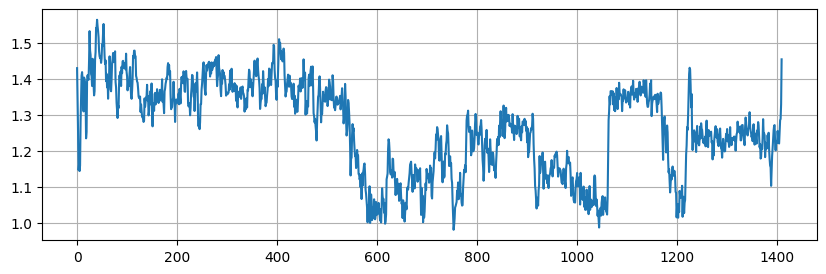

In [29]:
plt.subplots(figsize=(10, 3))

# The standardized ALPS statistic from the Supplementary Material of Crozier et. al. (2025)
std_alps = (dtda_vid.alps + 5.08)/(0.705 * np.log(np.prod(crop_vid.shape[1:])))
plt.plot(std_alps)
plt.grid(axis='both')